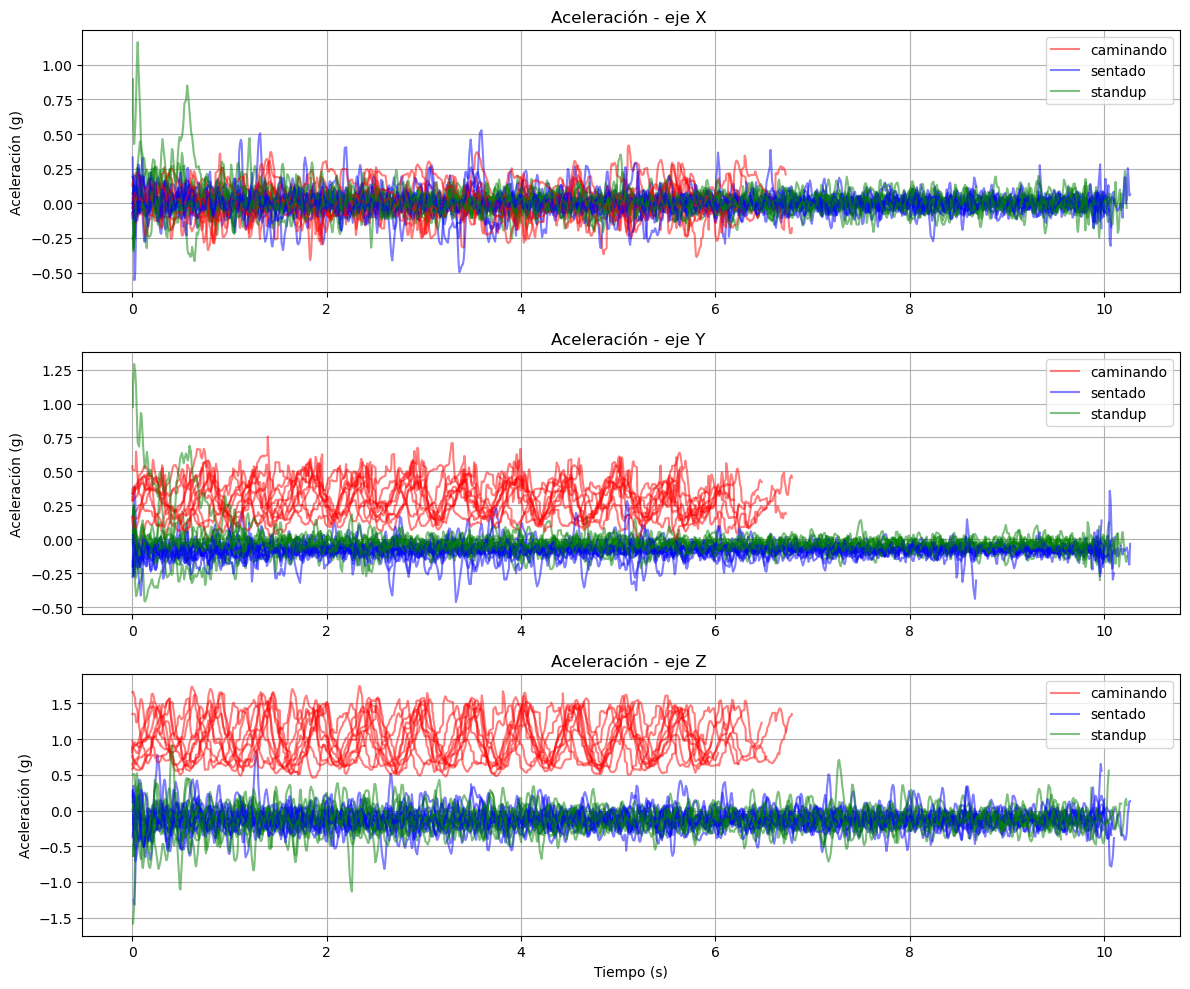

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os
import numpy as np

colors = {
    "caminando": "red",
    "sentado": "blue",
    "standup": "green"
}

csv_files = sorted(glob.glob("*.csv"))

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=False)
plotted = {"x": set(), "y": set(), "z": set()}

for file in csv_files:
    filename = os.path.basename(file)
    if "caminando" in filename.lower():
        activity = "caminando"
    elif "sentado" in filename.lower():
        activity = "sentado"
    elif "standup" in filename.lower() or "stand_up" in filename.lower():
        activity = "standup"
    else:
        continue


    df = pd.read_csv(file, comment="#", header=0, engine="python")

    time = pd.to_numeric(df.iloc[:, 0])
    acc_x = pd.to_numeric(df.iloc[:, 1])
    acc_y = pd.to_numeric(df.iloc[:, 2])
    acc_z = pd.to_numeric(df.iloc[:, 3] )


    label = activity if activity not in plotted["x"] else None
    axes[0].plot(time, acc_x, color=colors[activity], alpha=0.5, label=label)
    if label: plotted["x"].add(activity)

    label = activity if activity not in plotted["y"] else None
    axes[1].plot(time, acc_y, color=colors[activity], alpha=0.5, label=label)
    if label: plotted["y"].add(activity)

    label = activity if activity not in plotted["z"] else None
    axes[2].plot(time, acc_z, color=colors[activity], alpha=0.5, label=label)
    if label: plotted["z"].add(activity)


axes[0].set_title("Aceleración - eje X ")
axes[1].set_title("Aceleración - eje Y ")
axes[2].set_title("Aceleración - eje Z ")
axes[0].set_ylabel("Aceleración (g)")
axes[1].set_ylabel("Aceleración (g)")
axes[2].set_ylabel("Aceleración (g)")
axes[2].set_xlabel("Tiempo (s)")

for ax in axes:
    ax.grid(True)
    ax.legend(loc="upper right")

plt.tight_layout()
plt.show()



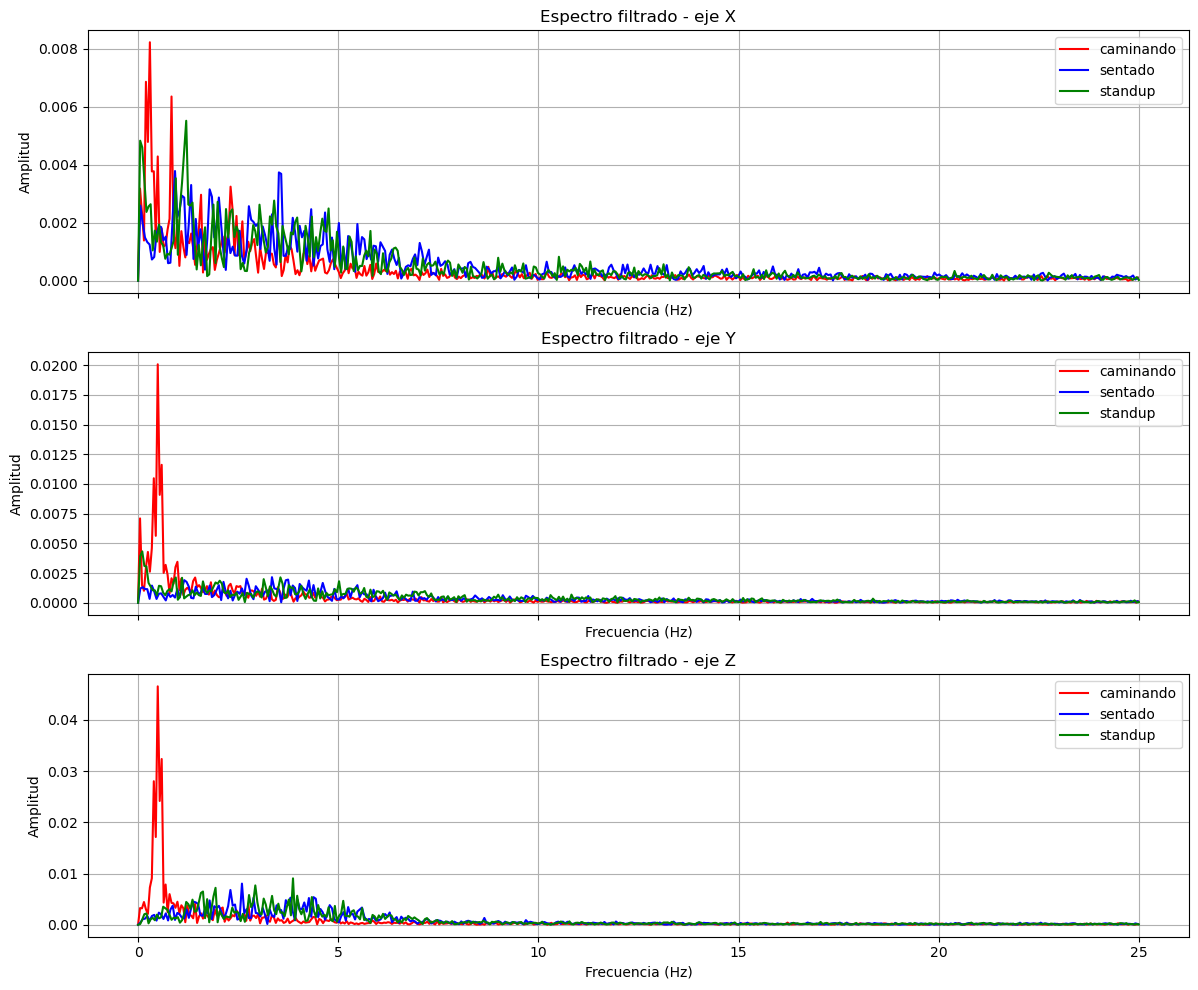

In [2]:
fs = 50  

data = {"caminando": [], "sentado": [], "standup": []}
for file in sorted(glob.glob("*.csv")):
    fname = os.path.basename(file).lower()
    if "caminando" in fname:
        activity = "caminando"
    elif "sentado" in fname:
        activity = "sentado"
    elif "standup" in fname or "stand_up" in fname:
        activity = "standup"
    else:
        continue

    df = pd.read_csv(file, comment="#", header=0, engine="python").dropna()
    data[activity].append(df.iloc[:, 1:4].to_numpy())  


mean_signals = {}
for activity, signals in data.items():
    if signals:
        min_len = min(s.shape[0] for s in signals)
        stacked = np.stack([s[:min_len] for s in signals])
        mean_signals[activity] = stacked.mean(axis=0)  

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
for i, eje in enumerate(["X", "Y", "Z"]):
    for activity, color in colors.items():
        if activity in mean_signals:
            acc = mean_signals[activity][:, i]
            N = len(acc)
            spec_cmplx = np.fft.rfft(acc)
            spec_cmplx[0] = 0  
            freqs = np.fft.rfftfreq(N, d=1/fs)
            spectrum = np.abs(spec_cmplx) / N
            axes[i].plot(freqs, spectrum, color=color, label=activity)

    axes[i].set_title(f"Espectro filtrado - eje {eje}")
    axes[i].set_xlabel("Frecuencia (Hz)")
    axes[i].set_ylabel("Amplitud")
    axes[i].grid(True)
    axes[i].legend()

plt.tight_layout()
plt.show()
